# Bluesky: social posts - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** X/Twitter and Facebook post access are closed (paid API
since 2023; CrowdTangle shut down 2024). **Bluesky is open**, except full-text search
needs auth, so we monitor *accounts* instead. You drive a coding agent (Codex, Claude
Code, or Antigravity CLI).


## About this data source

**Bluesky.** A public social network with an *open door*: anyone can read public posts
without an account, which is exactly what Twitter stopped allowing. Think of it as:
*"a Twitter-shaped network you are still allowed to read."*

- **Explore it in a browser:** <https://bsky.app/> (search *dengue* or *outbreak* in the
  site's own search box, then open a public-health account and scroll its feed, which is
  exactly what this notebook reads)

**The catch:** keyword search through the API needs a login, but *finding accounts* and
*reading their public posts* do not. So we watch **accounts**, not keywords.

> **What happened to the classics:** X/Twitter went paid-API in 2023; Facebook's CrowdTangle
> shut down in 2024 (research access by application only). Our own COVID exercise file still
> has Twitter, Kinsa and Cuebiq columns, and all three of those streams are now closed.
> Novel data streams are fragile.


## Step 1: discover public-health accounts

> *Using the public Bluesky AppView (https://public.api.bsky.app/xrpc, no auth), call*
> *app.bsky.actor.searchActors for terms like 'epidemiology', 'public health',*
> *'outbreak', 'infectious disease'. Build a watch list of handles + display names.*


In [1]:
# Agent's account discovery:
import os, json, re, time
import urllib.request, urllib.parse
import pandas as pd, matplotlib.pyplot as plt

UA = {"User-Agent": "SISMID2026-course/1.0 (your-email@example.com)"}


def cache_path(fname):
    for p in (f"../data/{fname}", f"data/{fname}", f"./{fname}"):
        if os.path.exists(p):
            return p
    return None


def get_json(url, timeout=45):
    return json.loads(urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read())


API = "https://public.api.bsky.app/xrpc"


def bsky(method, **params):
    """Call a public Bluesky AppView endpoint. No authentication needed for
    searchActors / getAuthorFeed / resolveHandle. (searchPosts DOES need auth.)"""
    return get_json(f"{API}/{method}?" + urllib.parse.urlencode(params))


SEEDS = ["epidemiology", "public health", "outbreak", "infectious disease",
         "virology", "global health"]


def discover_accounts(seeds=SEEDS, per_term=10):
    """Watch list of {handle: displayName} built from app.bsky.actor.searchActors
    over several public-health search terms. Falls back to the cache on failure."""
    accounts = {}
    try:
        for t in seeds:
            for a in bsky("app.bsky.actor.searchActors", q=t, limit=per_term).get("actors", []):
                accounts[a["handle"]] = a.get("displayName") or ""
            time.sleep(0.4)
        if not accounts:
            raise RuntimeError("no accounts returned (rate-limited?)")
    except Exception as e:
        print(f"Live discovery failed ({type(e).__name__}): {e}")
        p = cache_path("bluesky_health_accounts.csv")
        print("Using cached snapshot:", p)
        accounts = dict(pd.read_csv(p).fillna("").values)
    return accounts


accounts = discover_accounts()
pd.DataFrame(list(accounts.items()), columns=["handle", "displayName"]).to_csv(
    "../data/bluesky_health_accounts.csv", index=False)  # refresh the cache

print(f"{len(accounts)} accounts on the watch list, e.g.:")
for h, d in list(accounts.items())[:6]:
    print(f"   @{h:36s} {d[:40]}")


60 accounts on the watch list, e.g.:
   @epidemiology.bsky.social             Epidemiology!
   @jclinepi.bsky.social                 Journal of Clinical Epidemiology
   @amjepi.bsky.social                   American Journal of Epidemiology
   @harvardepi.bsky.social               Harvard Epidemiology
   @imsepidemiology.bsky.social          IMS Epidemiology, University of Cambridg
   @ises-epi.bsky.social                 International Social Epidemiology Societ


## Step 2: scan their public feeds

> *For each account call app.bsky.feed.getAuthorFeed (no auth) and pull recent posts.*
> *Flag posts mentioning disease keywords (dengue, influenza, covid, measles, rsv,*
> *outbreak, h5n1, malaria, mpox). Return a tidy table: date, handle, keywords, text.*
> *Use a WORD-BOUNDARY regex, not a substring test.*


In [2]:
# Agent's feed scan:
KEYWORDS = ["dengue", "influenza", "covid", "measles", "rsv", "outbreak", "h5n1",
            "malaria", "cholera", "mpox", "avian flu", "bird flu", "flu"]


def scan(accounts, n_accounts=25, per_account=50):
    """Scan each account's public feed (no auth) for disease-keyword mentions,
    using a WORD-BOUNDARY regex (not substring) so e.g. 'influence' never matches 'flu'.
    Returns (tidy DataFrame[date, handle, keywords, text], total posts scanned)."""
    pat = re.compile(r"\b(" + "|".join(re.escape(k) for k in KEYWORDS) + r")\b", re.I)
    rows, scanned = [], 0
    for h in list(accounts)[:n_accounts]:
        try:
            feed = bsky("app.bsky.feed.getAuthorFeed", actor=h, limit=per_account).get("feed", [])
        except Exception:
            continue
        for item in feed:
            rec = item.get("post", {}).get("record", {})
            txt = (rec.get("text") or "").replace("\n", " ").strip()
            scanned += 1
            hits = pat.findall(txt)
            if hits:
                rows.append({"date": (rec.get("createdAt") or "")[:10], "handle": h,
                            "keywords": ";".join(sorted({x.lower() for x in hits})),
                            "text": txt[:280]})
        time.sleep(0.25)
    return pd.DataFrame(rows), scanned


try:
    posts, scanned = scan(accounts)
    if posts.empty:
        raise RuntimeError("no matches (rate-limited?)")
    print(f"scanned {scanned} posts -> {len(posts)} keyword matches")
except Exception as e:
    print(f"Live scan failed ({type(e).__name__}): {e}")
    p = cache_path("bluesky_health_posts.csv")
    print("Using cached snapshot:", p)
    posts = pd.read_csv(p)

posts.to_csv("../data/bluesky_health_posts.csv", index=False)  # refresh the cache
posts.head()


scanned 1131 posts -> 100 keyword matches


,date,handle,keywords,text
0,2026-06-13,jclinepi.bsky.social,covid,A Systematic Review of Observational Studies o...
1,2026-05-07,harvardepi.bsky.social,covid;influenza,Join us on TODAY 5/7 at 1PM ET with Nick Reich...
2,2026-06-02,sheaepi.bsky.social,outbreak,"🧵3/4: Without full participation in WHO, the U..."
3,2026-06-02,sheaepi.bsky.social,outbreak,🧵1/4: The United States is at a critical momen...
4,2026-05-29,ichejournal.bsky.social,outbreak,New in ICHE: Ralstonia pickettii outbreak in p...


## Step 3: prove the word-boundary point

> *Show me the difference: count posts matching the substring 'flu' anywhere versus the*
> *word-boundary pattern \bflu\b, and print an example the substring version wrongly*
> *catches.*

**Why:** naive substring matching flags **"influence"** as flu. The pipeline runs fine
and returns confident nonsense. This is the verify habit in one bug.


In [3]:
# Agent's false-positive comparison:


## Step 4: summarise and save

> *Tally the keywords and plot them, print the five most recent outbreak posts, and save*
> *a tidy CSV.*


In [4]:
# Agent's tally + save:


## Bonus: weekly keyword post-counts (needs a free Bluesky account + app password)

> *Unlike the no-auth account-watching approach above, `app.bsky.feed.searchPosts`*
> *(auth required) returns a `hitsTotal` field alongside results — an actual aggregate*
> *count, not just a page of posts. It's capped at 10,000 per query, so a single*
> *unbounded search for a common term (e.g. "dengue") saturates the cap. But narrowing*
> *each query to a one-week window (`since`/`until`) keeps real counts under the cap,*
> *which turns this into a genuine weekly time series — the same idea as the Media*
> *Cloud weekly volume series in the news notebook, straight from Bluesky's own index.*

Get a free account at <https://bsky.app>, then create an **App Password** (not your login
password) at Settings -> App Passwords. Set `BSKY_HANDLE` and `BSKY_APP_PASSWORD` as
environment variables before starting the kernel. If they're not set, this cell skips
cleanly — everything above already works with no auth at all.


186 weeks, 2023-01-01 to 2026-07-19


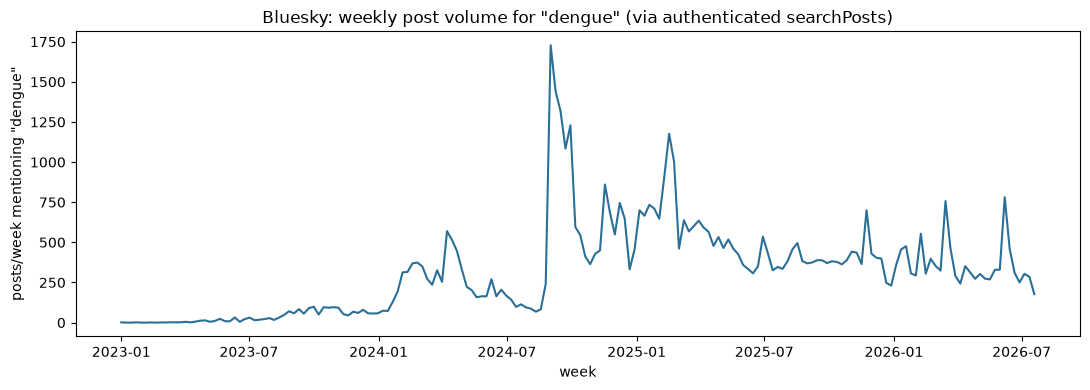

In [5]:
# Agent's authenticated weekly keyword-count series (optional, needs BSKY_HANDLE/BSKY_APP_PASSWORD):
BSKY_HANDLE = os.environ.get("BSKY_HANDLE")
BSKY_APP_PASSWORD = os.environ.get("BSKY_APP_PASSWORD")


def bsky_login(handle, app_password):
    """Authenticate to the AT Protocol entryway and return an access token.
    Uses an App Password, never the account's real login password."""
    req = urllib.request.Request(
        "https://bsky.social/xrpc/com.atproto.server.createSession",
        data=json.dumps({"identifier": handle, "password": app_password}).encode(),
        headers={"Content-Type": "application/json"}, method="POST")
    return json.loads(urllib.request.urlopen(req, timeout=30).read())["accessJwt"]


def weekly_post_counts(token, query, start, tries=3):
    """hitsTotal from app.bsky.feed.searchPosts, one call per calendar week from `start`
    to today. Each window is narrow enough to stay under the API's 10,000-hit cap for
    real disease keywords, so this is an actual weekly volume series, not an estimate."""
    weeks = pd.date_range(start, pd.Timestamp.today(), freq="W")
    rows = []
    for w in weeks:
        params = {"q": query, "limit": 1,
                  "since": w.strftime("%Y-%m-%dT00:00:00Z"),
                  "until": (w + pd.Timedelta(days=7)).strftime("%Y-%m-%dT00:00:00Z")}
        url = "https://bsky.social/xrpc/app.bsky.feed.searchPosts?" + urllib.parse.urlencode(params)
        req = urllib.request.Request(url, headers={"Authorization": f"Bearer {token}"})
        for attempt in range(tries):
            try:
                hits = json.loads(urllib.request.urlopen(req, timeout=30).read()).get("hitsTotal", 0)
                break
            except Exception:
                if attempt == tries - 1:
                    hits = None
                time.sleep(2)
        rows.append({"week": w, "count": hits})
    return pd.DataFrame(rows)


if BSKY_HANDLE and BSKY_APP_PASSWORD:
    token = bsky_login(BSKY_HANDLE, BSKY_APP_PASSWORD)
    weekly = weekly_post_counts(token, "dengue", "2023-01-01")
    weekly.to_csv("../data/bluesky_dengue_weekly_counts.csv", index=False)
    print(f"{len(weekly)} weeks, {weekly['week'].min().date()} to {weekly['week'].max().date()}")

    plt.figure(figsize=(11, 4))
    plt.plot(weekly["week"], weekly["count"], color="#2A6F97")
    plt.ylabel('posts/week mentioning "dengue"')
    plt.xlabel("week")
    plt.title("Bluesky: weekly post volume for \"dengue\" (via authenticated searchPosts)")
    plt.tight_layout()
    plt.savefig("../bluesky_dengue_weekly_counts.png", dpi=150)
    plt.show()
else:
    print("BSKY_HANDLE / BSKY_APP_PASSWORD not set -> skipping the authenticated weekly count series.")
    print("Free account: https://bsky.app -> Settings -> App Passwords")


## Reflection

- Account monitoring, not surveillance: small community, real selection bias.
- **Streams are fragile:** `covid_traces_WA.csv` still has Twitter, Kinsa and Cuebiq
  columns, and all three of those sources are now closed.
